# 🔧 WEEK 10 DAY 2: DATA PREPROCESSING
**Cleaning → Scaling → Encoding → Pipeline Ready**

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

df = pd.read_csv('../data/customer_churn.csv')
print('Raw data shape:', df.shape)

Raw data shape: (500, 9)


Missing values:
 CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


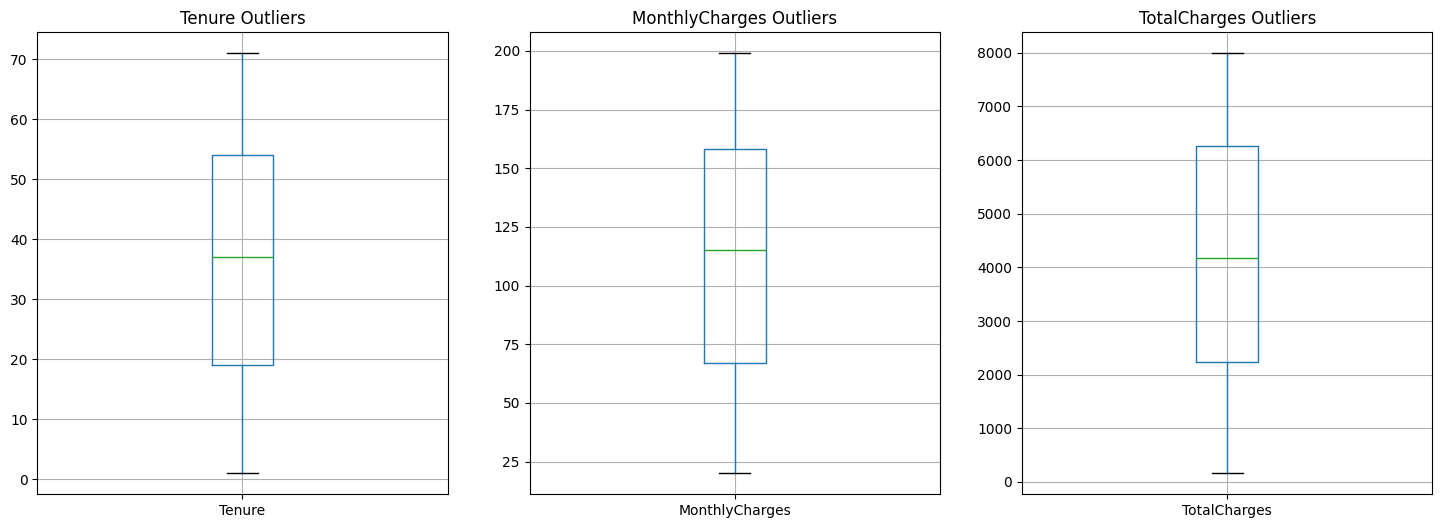

In [3]:
# 1. DATA CLEANING
print('Missing values:\n', df.isnull().sum())

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# OUTLIER DETECTION [plots/04_outlier_detection.png]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, col in enumerate(['Tenure', 'MonthlyCharges', 'TotalCharges']):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'{col} Outliers')
plt.savefig('../plots/04_outlier_detection.png', dpi=300)
plt.show()

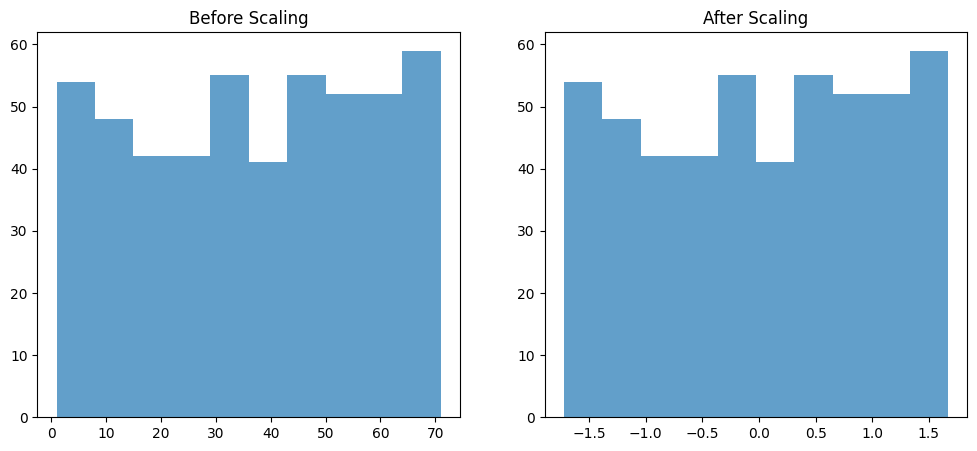

✅ Preprocessing pipeline ready


In [4]:
# 2. PREPROCESSING PIPELINE
numeric_features = ['Tenure', 'MonthlyCharges']
categorical_features = ['Contract', 'PaymentMethod']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

# Test scaling [plots/03_scaling_comparison.png]
X_sample = df[numeric_features]
X_scaled = preprocessor.fit_transform(df[numeric_features + categorical_features])[:, :2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(X_sample['Tenure'], alpha=0.7)
ax1.set_title('Before Scaling')
ax2.hist(X_scaled[:, 0], alpha=0.7)
ax2.set_title('After Scaling')
plt.savefig('../plots/03_scaling_comparison.png', dpi=300)
plt.show()

print('✅ Preprocessing pipeline ready')